# Modeling a Damaging but Resolving Immune Response in PASC

### Overview
This notebook details a hypothesized Ordinary Differential Equation (ODE) model to simulate the dynamics of the immune response in the lungs of patients with Post-Acute Sequelae of COVID-19 (PASC).

The goal of this model is to translate static gene expression signatures into a dynamic system that can explore the mechanisms behind chronic inflammation and lung damage. The final model represents a biologically plausible scenario where an initial, aggressive immune response causes significant, permanent tissue damage, but the underlying inflammation eventually subsides.

### Part 1: The Conceptual Model

The model is based on the interaction between three key populations:
* **Healthy Lung Cells (L)**
* **Activated Cytotoxic T-Cells (T)**
* **Interferon-gamma (IFN-γ)**, a key inflammatory cytokine (I)

The model tells the following story:
1. A strong population of **T-cells (T)** is initially present, activated by the prior viral infection.
2. These T-cells produce **IFN-γ (I)**, which transiently boosts the immune response.
3. While active, the T-cells destroy **Lung Cells (L)**. The damage is most rapid when the T-cell population is at its peak.
4. Without a persistent stimulus, the T-cell population naturally decays over time. As the T-cells die off, the rate of lung damage slows and eventually stops, leaving the patient with permanent but stable lung damage.

### Part 2: The Mathematical Model (ODEs)

This biological narrative is translated into the following system of equations.

---

##### **Equation 1: Change in Lung Cells (dL/dt)**
*The rate of lung cell destruction is proportional to the interaction between lung cells and T-cells.*

$$
\frac{dL}{dt} = -\gamma \cdot L \cdot T
$$

* **γ (gamma)**: The rate constant of T-cell-mediated killing.

---

##### **Equation 2: Change in T-cells (dT/dt)**
*The T-cell population is amplified by IFN-γ feedback and reduced by a more dominant natural decay.*

$$
\frac{dT}{dt} = \underbrace{\alpha \cdot T \cdot I}_{\text{IFN-}\gamma \text{ driven activation}} - \underbrace{\delta_T \cdot T}_{\text{Natural decay}}
$$

* **α (alpha)**: The rate of IFN-γ-dependent T-cell activation.
* **δ_T (delta_T)**: The natural decay rate of T-cells.

---

##### **Equation 3: Change in IFN-γ (dI/dt)**
*The IFN-γ concentration increases via T-cell production and decreases via natural decay.*

$$
\frac{dI}{dt} = \underbrace{\beta \cdot T}_{\text{Production by T-cells}} - \underbrace{\delta_I \cdot I}_{\text{Natural decay}}
$$

* **β (beta)**: The rate of IFN-γ production per T-cell.
* **δ_I (delta_I)**: The natural decay rate of IFN-γ.

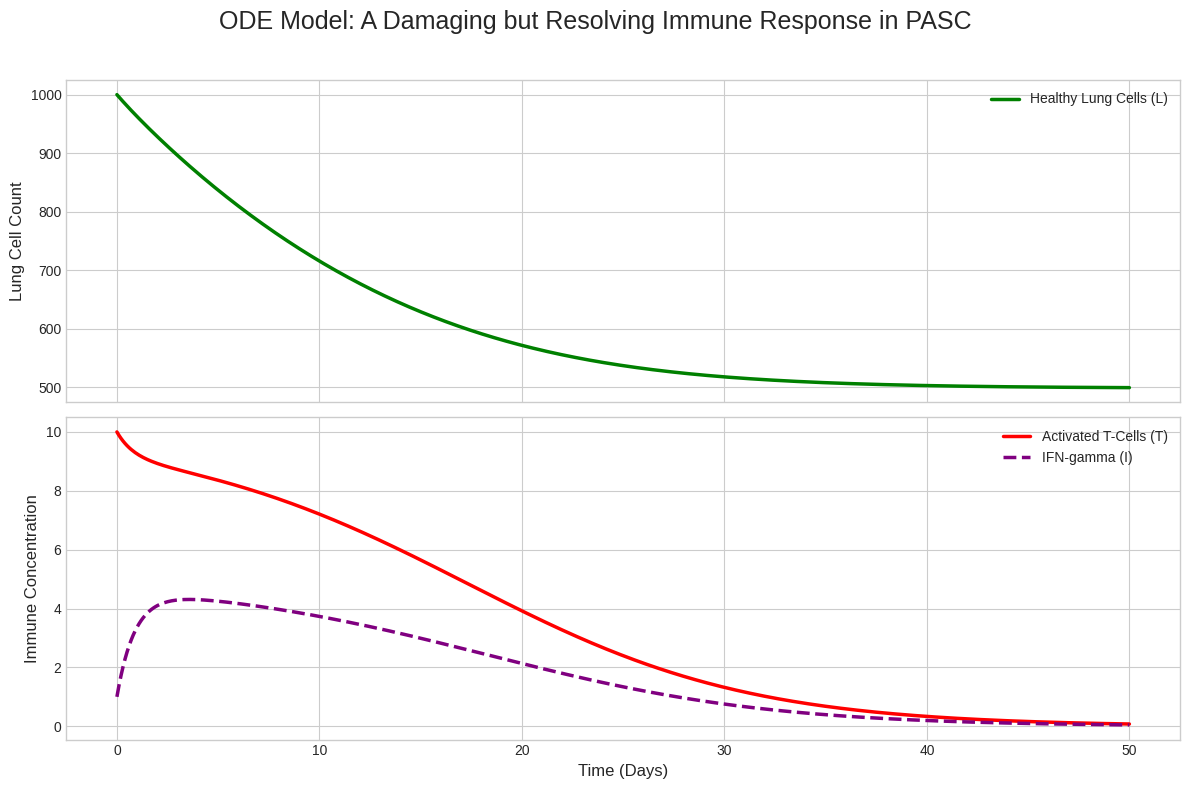

In [1]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# Define the ODE model
def pasc_model(y, t, alpha, beta, gamma, delta_T, delta_I):
    L, T, I = y
    dLdt = -gamma * L * T
    dTdt = alpha * T * I - delta_T * T
    dIdt = beta * T - delta_I * I
    return [dLdt, dTdt, dIdt]

# --- Simulation Setup ---

# 1. PARAMETERS for a pathological but stable model
alpha   = 0.03
beta    = 0.5
gamma   = 0.004
delta_T = 0.15
delta_I = 1.0

# 2. SET INITIAL CONDITIONS [L0, T0, I0]
L0 = 1000
T0 = 10
I0 = 1
y0 = [L0, T0, I0]

# 3. SET TIME VECTOR
t = np.linspace(0, 50, 500)

# 4. SOLVE THE ODE SYSTEM
solution = odeint(pasc_model, y0, t, args=(alpha, beta, gamma, delta_T, delta_I))

# 5. PLOT THE RESULTS ON SEPARATE SUBPLOTS FOR CLARITY
plt.style.use('seaborn-v0_8-whitegrid')

# Create a figure with 2 vertically stacked subplots that share an x-axis
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

fig.suptitle('ODE Model: A Damaging but Resolving Immune Response in PASC', fontsize=18)

# --- Top Plot: Lung Cells ---
ax1.plot(t, solution[:, 0], label='Healthy Lung Cells (L)', color='green', linewidth=2.5)
ax1.set_ylabel('Lung Cell Count', fontsize=12)
ax1.legend()
ax1.grid(True)

# --- Bottom Plot: T-Cells and IFN-gamma ---
ax2.plot(t, solution[:, 1], label='Activated T-Cells (T)', color='red', linewidth=2.5)
ax2.plot(t, solution[:, 2], label='IFN-gamma (I)', color='purple', linestyle='--', linewidth=2.5)
ax2.set_ylabel('Immune Concentration', fontsize=12)
ax2.set_xlabel('Time (Days)', fontsize=12)
ax2.legend()
ax2.grid(True)

# Improve layout and show the plot
plt.tight_layout(rect=[0, 0, 1, 0.96]) # Adjust for suptitle
plt.show()

### Part 3: Final Model Outcome and Interpretation

Running the Python code in the cell above generates a simulation of our hypothesized system.

**Interpretation of the plot:**

* **Lung Cell Count (Top Panel)**: The population of healthy lung cells declines sharply at the beginning, when the immune response is strongest. The rate of decline slows as the T-cell population wanes, eventually stabilizing at a new, lower baseline (~50% of the original count). This represents permanent tissue damage.

* **Immune Concentration (Bottom Panel)**: The T-cell population (red line) starts at a high level and steadily decreases over 40-50 days, showing the immune response is clearing itself out. The IFN-γ concentration (purple line) spikes briefly as the T-cells are initially active but then also decays as its source (the T-cells) disappears.

This model successfully visualizes the hypothesis of a patient who suffers significant lung damage from an acute inflammatory phase, but whose immune system eventually returns to a non-inflammatory baseline, leaving them with stable, long-term sequelae.